# Day 19

#### Start with what we missed yesterday: Independent Component Analysis


When the components are statistically independent (fitting name right), we can use ICA to separate mixed components.

The classical example is the so-called "cocktail party" problem. This is illustrated in the following figure from Hastie, Tibshirani, & Friedman. Think of the "source signals" as two voices at a party. You are trying to concentrate on just one voice. What you hear is something like the "measured signals" pattern. You could run the data through PCA and that would do an excellent job of reconstructing the signal with reduced dimensionality, but it wouldn't actually isolate the different physical components (bottom-left panel). ICA on the other hand can (bottom-right panel).

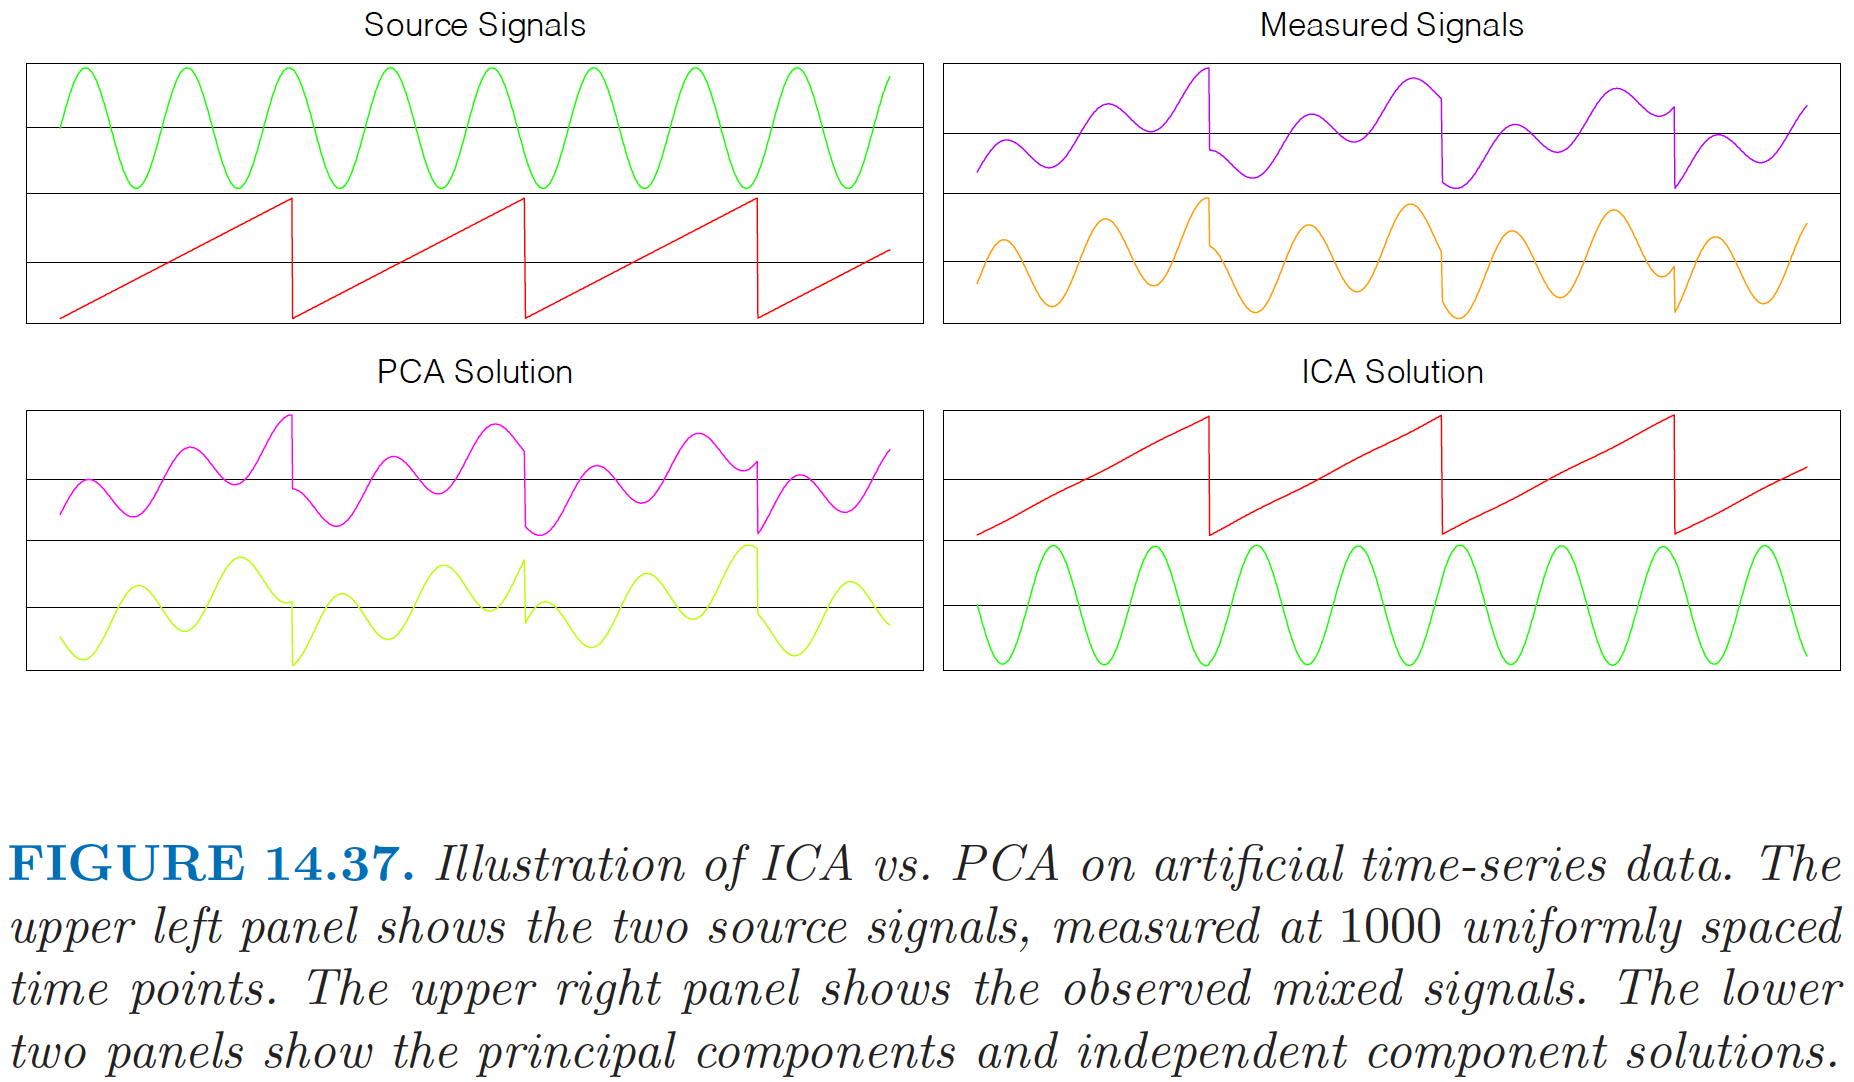

So let's say we have two sources $S_1(t)$, $S_2(t)$ but the microphones may record:

$$x_1(t) = 0.8S_1(t) + 0.3S_2(t) \qquad \qquad x_2(t) = 0.4S_1(t) + 0.9S_2(t)$$

We never directly observe $s_1$ or $s_2$ but we see their mixtures.

In matrix form this looks like $\mathbf{x} = \mathbf{AS}$

Ideally, then we can find $\mathbf{S = A^{-1}x}$

But we do not not the inverse of A, so ICA tries an unmixing matrix $\mathbf{W \approx A^{-1}}$ such that $\mathbf{\hat{S} = WX}$

**ICA here makes the components independent, whereas PCA from before makes it uncorrelated**

We know that when we mix things, things start to look more Gaussian due to CLT. So we want to apply the opposite logic for unmixing and go towards high non-gaussianity. This helps find independent sources.

> ICA is good for complex systems with relatively independent systems. For example, a galaxy is roughly a linear combination of cool and hot stars. We want eigenvectors that are aligned with these physical traits/regions.


In [1]:
# Execute this cell
import numpy as np
from sklearn.decomposition import FastICA

X = np.random.normal(size=(100,2)) # 100 objects in 2D
R = np.random.random((2,5)) # mixing matrix
X = np.dot(X,R) # Simulation of a 5D data space

ica = FastICA(n_components=2) # Now reproject to 2-D
ica.fit(X)

proj = ica.transform(X) # 100x2 projection of the data
comp = ica.components_ # 2x5 matrix of independent components
## sources = ica.sources_ # 100x2 matrix of sources